# Detector bake-off — best AI head on the frozen foundation (injection truth)

Scores each detector **head** by catalogue-independent **injection-recovery** (the metric
that actually shows whether we go beyond MER), not by MER agreement:

- **50% point-source depth** (deeper = better) from all-10-band injection recovery.
- **Multi-band gain** = recovery(all-10-band) − recovery(VIS-only) — the foundation's
  value over a VIS-only detector (sources MER's VIS catalogue can't get).
- **Cleanliness** = multi-detections-per-bright-star + on-spike fraction (lower = better).

Candidates (trained on the 24-tile bake-off subset, round 1): CenterNet / StemCenterNet ×
vis_sep / vis_peak labels. Reference lines (no retrain): production r2 + MER-finetune.
Evaluated on 16 **held-out** tiles. Missing checkpoints are skipped automatically.

Set `N_PER_MAG` / `EVAL_N` higher for the final run; defaults are fast-screen values.

In [1]:
import sys
from pathlib import Path
import numpy as np, torch

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root()
for p in [REPO/'models',REPO/'models'/'detection',REPO/'models'/'astrometry2']:
    if str(p) not in sys.path: sys.path.insert(0,str(p))

from load_foundation import load_foundation
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper
from detection.stem_centernet_detector import StemCenterNetDetector
from detection.validation_utils import load_mer, eval_injection, build_inputs, run_detect, _wcs_vis
from detection.dataset import _vis_bright_core_and_spike_mask
from scipy.spatial import cKDTree

DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ENC = REPO/'models'/'checkpoints'/'jaisp_v10_warmstart'/'checkpoint_best.pt'
MER_FITS = REPO/'data'/'edf_s_ood'/'catalogs_compact'/'mer_FINAL_q1_ECDFS_footprint.fits'
EUC, RUB = str(REPO/'data'/'euclid_tiles_200'), str(REPO/'data'/'rubin_tiles_200')
OUT = REPO/'paper'/'figures'/'detector_bakeoff_confirm.png'

# --- eval config (bump for final run) ---
EVAL_N    = 16                    # held-out tiles to use (<=16)
N_PER_MAG = 12                    # injections per mag bin per tile
MAGS      = (23.0, 24.0, 24.5, 25.0, 25.5, 26.0)
CLEAN_N   = 6                     # tiles for cleanliness metric

EVAL_STEMS = (REPO/'data'/'bakeoff_eval16_stems.txt').read_text().split()[:EVAL_N]
print(f'device {DEV}, eval tiles {len(EVAL_STEMS)}, n_per_mag {N_PER_MAG}')

# candidate registry: name -> (kind, ckpt, conf, group)
C = REPO/'checkpoints'
CANDIDATES = [
    ('CenterNet · vis_sep',  'cn', C/'centernet_v10_sep_r1'/'centernet_best.pt',          0.30, 'subset r1'),
    ('CenterNet · vis_peak', 'cn', C/'centernet_v10_vispeak_r1'/'centernet_best.pt',       0.30, 'subset r1'),
    ('StemCN · vis_sep',     'st', C/'stem_centernet_v10_sep_r1'/'stem_centernet_best.pt', 0.55, 'subset r1'),
    ('StemCN · vis_peak',    'st', C/'stem_centernet_v10_vispeak_r1'/'stem_centernet_best.pt',0.55,'subset r1'),
    ('ref: CenterNet r2',    'cn', C/'centernet_v10_uncertain_synth_r2'/'centernet_best.pt',0.30, 'reference'),
    ('ref: StemCN r2',       'st', C/'stem_centernet_v10_uncertain_synth_r2'/'stem_centernet_best.pt',0.55,'reference'),
]
CANDIDATES = [(n,k,p,cf,g) for (n,k,p,cf,g) in CANDIDATES if Path(p).exists()]
print('present candidates:'); [print('  ', n) for n,_,_,_,_ in CANDIDATES]

device cuda, eval tiles 16, n_per_mag 12
present candidates:
   CenterNet · vis_sep
   CenterNet · vis_peak
   StemCN · vis_sep
   StemCN · vis_peak
   ref: CenterNet r2
   ref: StemCN r2


[None, None, None, None, None, None]

In [2]:
mer = load_mer(str(MER_FITS))
print('loading frozen foundation (shared by all heads) ...')
foundation = load_foundation(str(ENC), device=DEV, freeze=True)
enc = JAISPEncoderWrapper(foundation, freeze=True).to(DEV).eval()

def get_det(kind, ckpt):
    if kind=='cn': return CenterNetDetector.load(str(ckpt), encoder=enc, device=DEV).eval()
    return StemCenterNetDetector.load(str(ckpt), foundation, device=DEV).eval()

def depth50(curve_mags, comp):
    # first mag (faint-ward) where completeness drops below 0.5, linearly interpolated
    comp = np.asarray(comp); m = np.asarray(curve_mags)
    for i in range(len(m)-1):
        if comp[i] >= 0.5 >= comp[i+1]:
            t = (0.5-comp[i])/((comp[i+1]-comp[i]) or -1e-9)
            return float(m[i] + t*(m[i+1]-m[i]))
    return float(m[-1]) if comp[-1] >= 0.5 else float(m[0])

def cleanliness(det, conf, stems):
    mstar_tot=cores_tot=0; onspk=[]
    for st in stems:
        ed=dict(np.load(f'{EUC}/{st}_euclid.npz',allow_pickle=True)); rd=dict(np.load(f'{RUB}/{st}.npz',allow_pickle=True))
        images,rms,vh=build_inputs(ed,rd); vis=images['euclid_VIS']
        xy=run_detect(det,images,rms,vh,DEV,conf)
        bx,by,spike=_vis_bright_core_and_spike_mask(np.asarray(vis,np.float32))
        if len(xy):
            xi=np.clip(xy[:,0].round().astype(int),0,vis.shape[1]-1); yi=np.clip(xy[:,1].round().astype(int),0,vis.shape[0]-1)
            onspk.append(100*spike[yi,xi].mean())
        if len(bx) and len(xy):
            d=cKDTree(xy).query_ball_point(np.stack([bx,by],1),r=10.0)
            mstar_tot+=sum(1 for x in d if len(x)>1); cores_tot+=len(bx)
    return (mstar_tot/max(cores_tot,1)), (np.mean(onspk) if onspk else 0.0)

results=[]
for name,kind,ckpt,conf,grp in CANDIDATES:
    print(f'\n=== {name} (conf {conf}) ===')
    det=get_det(kind,ckpt)
    rec=eval_injection(det,EVAL_STEMS,mer,EUC,RUB,DEV,modes=('all','vis'),
                       target_mags=MAGS,n_per_mag=N_PER_MAG,conf=conf)
    c_all=[rec['all'][m][0]/max(rec['all'][m][1],1) for m in MAGS]
    c_vis=[rec['vis'][m][0]/max(rec['vis'][m][1],1) for m in MAGS]
    gain=[a-v for a,v in zip(c_all,c_vis)]
    d50=depth50(MAGS,c_all)
    mstar,onspk=cleanliness(det,conf,EVAL_STEMS[:CLEAN_N])
    results.append(dict(name=name,grp=grp,c_all=c_all,c_vis=c_vis,gain=gain,d50=d50,
                        gain_peak=max(gain),mstar=mstar,onspk=onspk))
    print(f'  50% depth(all)={d50:.2f}  peak multiband gain={max(gain)*100:.0f}pp  multistar={mstar:.2f}/core  on-spike={onspk:.1f}%')
    del det
    if DEV.type=='cuda': torch.cuda.empty_cache()

print('\n\n================ SCOREBOARD ================')
print(f'{"head":24s} {"50% depth":>9} {"mb gain":>8} {"multistar":>9} {"on-spike":>8}')
for r in sorted(results,key=lambda r:-r['d50']):
    print(f'{r["name"]:24s} {r["d50"]:9.2f} {r["gain_peak"]*100:7.0f}p {r["mstar"]:9.2f} {r["onspk"]:7.1f}%')

loading frozen foundation (shared by all heads) ...


JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]


Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt

=== CenterNet · vis_sep (conf 0.3) ===


  50% depth(all)=25.69  peak multiband gain=54pp  multistar=0.01/core  on-spike=15.5%

=== CenterNet · vis_peak (conf 0.3) ===


  50% depth(all)=25.92  peak multiband gain=44pp  multistar=0.01/core  on-spike=11.1%

=== StemCN · vis_sep (conf 0.55) ===


  50% depth(all)=25.80  peak multiband gain=4pp  multistar=0.01/core  on-spike=9.2%

=== StemCN · vis_peak (conf 0.55) ===


  50% depth(all)=25.84  peak multiband gain=3pp  multistar=0.00/core  on-spike=8.5%

=== ref: CenterNet r2 (conf 0.3) ===


  50% depth(all)=25.74  peak multiband gain=15pp  multistar=0.01/core  on-spike=12.4%

=== ref: StemCN r2 (conf 0.55) ===


  50% depth(all)=25.76  peak multiband gain=2pp  multistar=0.02/core  on-spike=7.9%


================ SCOREBOARD ================
head                     50% depth  mb gain multistar on-spike
CenterNet · vis_peak         25.92      44p      0.01    11.1%
StemCN · vis_peak            25.84       3p      0.00     8.5%
StemCN · vis_sep             25.80       4p      0.01     9.2%
ref: StemCN r2               25.76       2p      0.02     7.9%
ref: CenterNet r2            25.74      15p      0.01    12.4%
CenterNet · vis_sep          25.69      54p      0.01    15.5%


saved -> /home/shemmati/Work/Projects/JAISP/paper/figures/detector_bakeoff_confirm.png


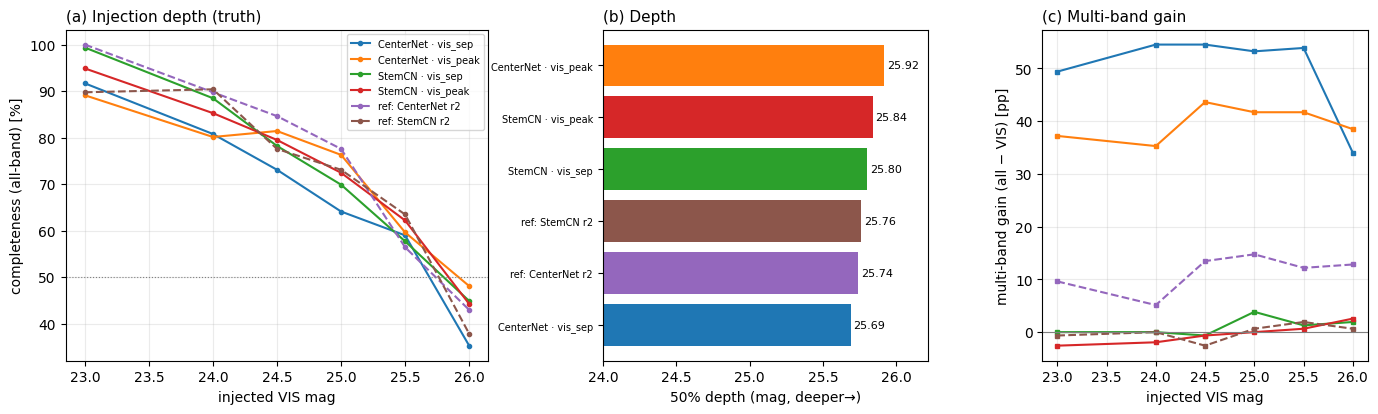

In [3]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

if not results:
    print('No checkpoints found yet — train the candidates first, then re-run.')
else:
    fig=plt.figure(figsize=(14,4.6))
    gs=GridSpec(1,3,width_ratios=[1.3,1,1],wspace=0.32,left=0.05,right=0.98,top=0.88,bottom=0.16)
    cmap=plt.cm.tab10
    col={r['name']:cmap(i%10) for i,r in enumerate(results)}

    ax=fig.add_subplot(gs[0,0])
    for r in results:
        ls='-' if r['grp']=='subset r1' else '--'
        ax.plot(MAGS,np.array(r['c_all'])*100,ls,marker='o',ms=3,color=col[r['name']],label=r['name'])
    ax.axhline(50,color='gray',lw=0.8,ls=':'); ax.set_xlabel('injected VIS mag'); ax.set_ylabel('completeness (all-band) [%]')
    ax.set_title('(a) Injection depth (truth)',loc='left',fontsize=11); ax.grid(alpha=0.25); ax.legend(fontsize=7)

    ax=fig.add_subplot(gs[0,1])
    rs=sorted(results,key=lambda r:r['d50']); y=np.arange(len(rs))
    ax.barh(y,[r['d50'] for r in rs],color=[col[r['name']] for r in rs])
    ax.set_yticks(y); ax.set_yticklabels([r['name'] for r in rs],fontsize=7); ax.set_xlim(24, max(r['d50'] for r in rs)+0.3)
    for i,r in enumerate(rs): ax.text(r['d50']+0.02,i,f"{r['d50']:.2f}",va='center',fontsize=8)
    ax.set_xlabel('50% depth (mag, deeper→)'); ax.set_title('(b) Depth',loc='left',fontsize=11)

    ax=fig.add_subplot(gs[0,2])
    for r in results:
        ls='-' if r['grp']=='subset r1' else '--'
        ax.plot(MAGS,np.array(r['gain'])*100,ls,marker='s',ms=3,color=col[r['name']])
    ax.axhline(0,color='gray',lw=0.8); ax.set_xlabel('injected VIS mag'); ax.set_ylabel('multi-band gain (all − VIS) [pp]')
    ax.set_title('(c) Multi-band gain',loc='left',fontsize=11); ax.grid(alpha=0.25)

    fig.savefig(OUT,dpi=200,bbox_inches='tight',facecolor='white'); print('saved ->',OUT); plt.show()